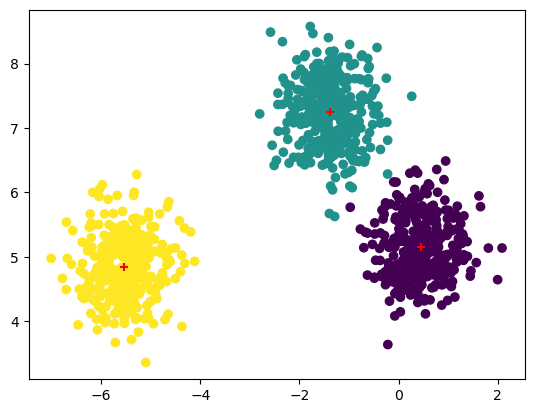

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

class GMM:
    """
    高斯混合聚类
    参数：
    k：聚类数
    max_iter：最大迭代次数
    """
    def __init__(self, k, max_iter=100):
        self.k = k
        self.max_iter = max_iter
        self.miu = None # 均值
        self.sigma = None # 方差
        self.alpha = None # 混合系数
        self.labels = None # 聚类结果

    def Gaussian(self,x,miu,sigma):
        """多元高斯分布"""
        n = len(miu)
        sigma = sigma + 1e-6*np.eye(n) # 引入正则化项，防止协方差矩阵奇异
        return 1.0/((2*np.pi)**(n/2)*np.linalg.det(sigma)**0.5)*np.exp(-0.5*np.dot(np.dot((x-miu).T,np.linalg.inv(sigma)),x-miu))
    
    def fit(self,X):
        """训练"""
        m,n = X.shape
        # 初始化高斯混合分布的模型参数
        # miu为k个n维向量
        idx = np.random.choice(m,self.k,replace=False)
        self.miu = X[idx]
        # sigma为k个n×n对称正定矩阵
        self.sigma =  np.random.rand(self.k,n,n)
        self.sigma = np.array([np.dot(sigma,sigma.T) for sigma in self.sigma])
        # 初始化alpha为均匀分布
        self.alpha = np.ones(self.k)/self.k
        # self.miu = X[[5,21,26]]
        # self.sigma = np.array([[[0.1,0],[0,0.1]]]*3)
        # self.alpha = np.array([1/3,1/3,1/3])

        # EM算法
        for i in range(self.max_iter):
            # E步
            # 计算每个样本属于每个高斯分布的概率
            p = np.zeros((m,self.k))
            for j in range(m):
                for k in range(self.k):
                    p[j,k] = self.alpha[k]*self.Gaussian(X[j],self.miu[k],self.sigma[k])
            p /= np.sum(p,axis=1,keepdims=True) # 归一化

            # M步
            # 更新高斯分布的模型参数
            for k in range(self.k):
                Nk = np.sum(p[:,k])
                self.miu[k] = np.sum(p[:,k].reshape(-1,1)*X,axis=0)/Nk
                self.sigma[k] = np.dot((X-self.miu[k]).T,p[:,k].reshape(-1,1)*(X-self.miu[k]))/Nk
                self.alpha[k] = Nk/m

        # 划分簇
        self.labels = np.argmax(p,axis=1)
       
        
if __name__ == '__main__':
    # 加载数据
    data,y = make_blobs(n_samples=1000,centers=3,n_features=3,cluster_std=0.5)
    # data = np.loadtxt('./Data/4.0.csv',dtype = float,delimiter = ',')
    # 实例化
    gmm = GMM(k=3,max_iter=100)
    # 训练
    gmm.fit(data)
    # 可视化
    plt.scatter(data[:,0],data[:,1],c=gmm.labels)
    plt.scatter(gmm.miu[:,0],gmm.miu[:,1],marker='+',c='r')
    plt.show()